# Chapter 8 — Spectral kernels and Bochner

*Companion notebook to **The Learned Kernel**, Ch. 8. Run top to bottom.*

By **Bochner's theorem** a continuous stationary kernel is the Fourier transform of a
finite nonnegative measure on frequencies — the *spectral measure*. So choosing a
stationary geometry **is** choosing a measure on frequencies, and learning the kernel is
learning that measure. We build the **finite multi-scale spectral kernel** — a Laplace
readout over a cosine/sine spectral embedding φ, with H banks fused convexly,

$$ k(x,x') = \sum_h w_h\, e^{-\|\phi_h(x)-\phi_h(x')\| / T_h}, \qquad w\in\Delta^{H-1}, $$

and show two things: it recovers and **extrapolates** a periodic structure a single RBF
cannot, and — separately — that the **readout** (Laplace vs Gaussian), not the spectrum,
sets the *roughness* of the function class.

**The frame** — *what is learned · how scored · what you read off.* We learn a finite
atomic spectral measure (frequency atoms read off the data, a fused Laplace bandwidth). We
score it by held-out **query-fold** KRR error (Ch. 7's leakage-free split). We read off the
spectral measure: broadband near zero = a smooth trend; a peak away from zero = structure at
a definite scale.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import set_style
from lkbook.chapters import ch08

set_style()

## 8.1  The readout sets the roughness

The smoothness of a stationary kernel is read from the singularity of its radial profile at
the origin, captured by the intrinsic semimetric d_k² = k(x,x) − 2k(x,x′) + k(x′,x′). The
RBF profile e^(−r²/T²) is analytic (order-2, C^∞); the Laplace e^(−r/T) has a cusp
(order-1, H^((d+1)/2), the Matérn-½ / ReLU-NTK class). On a genuinely rough target — an
Ornstein–Uhlenbeck (H^½) sample path — with the bandwidth chosen identically for both, the
Laplace fit tracks kinks the RBF rounds off.

In [3]:
r = ch08.roughness_ladder_demo(seed=0)
tbl = pd.DataFrame(
    {"fit RMSE (rough OU path)": {"Laplace readout (H^(d+1)/2)": round(r["laplace_rmse"], 3),
                                  "RBF readout (C^∞)": round(r["rbf_rmse"], 3)}})
print("same spectrum class, same selection — the readout alone moves the fit:")
tbl

same spectrum class, same selection — the readout alone moves the fit:


,fit RMSE (rough OU path)
Laplace readout (H^(d+1)/2),0.249
RBF readout (C^∞),0.352


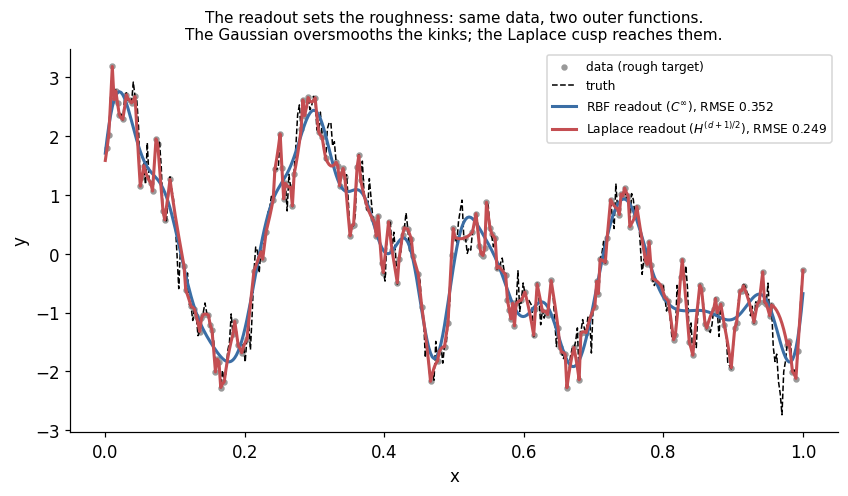

In [4]:
ch08.make_roughness_figure(seed=0)
plt.show()

The Laplace readout admits a class of functions the RBF's RKHS does not contain. No
bandwidth tuning recovers the rough component a C^∞ kernel excludes — the **roughness gate**.

## 8.2  Why one bandwidth is not enough, and Bochner's cure

A single RBF has one knee, at frequency |ω| ~ 1/T. A smooth-plus-periodic target has energy
at two separated scales; one bandwidth cannot serve both. The finite spectral-Laplace kernel
places mass at several frequencies at once — its frequency support is read off the data by a
periodogram. Watch it recover the periodic frequency and **extrapolate** it, where the RBF
reverts to the mean.

In [5]:
d = ch08.periodic_extrapolation_demo(seed=0)
print(f"true frequency            {d['true_freq']:.2f}")
print(f"recovered peak frequency  {d['recovered_freq']:.2f}")
print(f"RBF bandwidth (selected)  {d['ell']:.3f}")
tbl = pd.DataFrame({
    "in-hull test RMSE": {"spectral-Laplace": round(d["sm_test_rmse"], 3),
                          "single RBF": round(d["rbf_test_rmse"], 3)},
    "extrapolation RMSE": {"spectral-Laplace": round(d["sm_extrap_rmse"], 3),
                           "single RBF": round(d["rbf_extrap_rmse"], 3)},
})
tbl

true frequency            3.00
recovered peak frequency  2.99
RBF bandwidth (selected)  0.190


,in-hull test RMSE,extrapolation RMSE
spectral-Laplace,0.037,0.833
single RBF,0.028,1.142


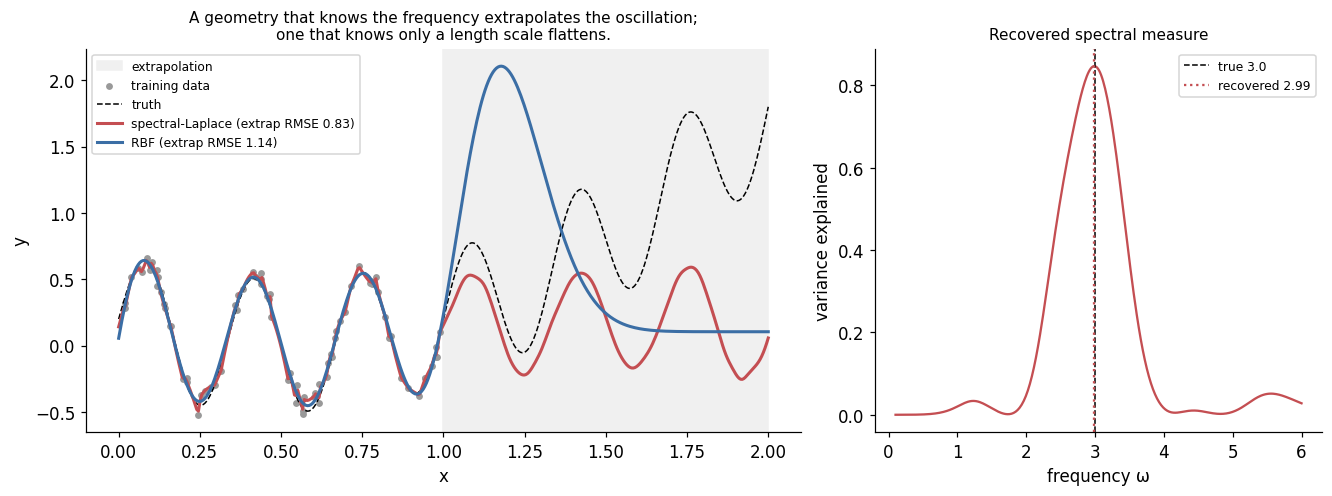

In [6]:
ch08.make_periodic_figure(seed=0)
plt.show()

The spectral kernel learned a *frequency*, so it carries the oscillation beyond the data
hull. The RBF learned a *length scale*, so it flattens. The measure is the geometry.

## 8.3  PSD and unit diagonal by construction

The fused Laplace kernel is PSD (a convex combination of PSD Laplace banks) and unit-diagonal
(each bank has k(x,x) = 1 and the weights sum to one).

In [7]:
omegas = np.array([0.0, 0.5, 3.0, 6.0])    # trend atoms + a periodic frequency + harmonic
amps = np.ones_like(omegas)
k = ch08.SpectralLaplaceKernel(omegas, amps, T=[0.5, 1.5], w=[0.6, 0.4])   # two fused banks
X = np.sort(np.random.RandomState(0).uniform(0, 1, 80))
K = k.gram(X, X)
print(f"diagonal mean   = {np.diag(K).mean():.4f}  (= 1, each bank unit-diagonal, w sums to 1)")
print(f"min eigenvalue  = {np.linalg.eigvalsh(K).min():.2e}  (>= 0  =>  PSD)")

diagonal mean   = 1.0000  (= 1, each bank unit-diagonal, w sums to 1)
min eigenvalue  = 1.78e-02  (>= 0  =>  PSD)


## 8.4  The measure is the geometry, on California

Read the per-feature spectral measure off California by periodogram. Median income
concentrates mass near zero (a smooth trend); latitude spreads its mass to higher scales
(structure at a definite scale). You read the geometry straight off the measure.

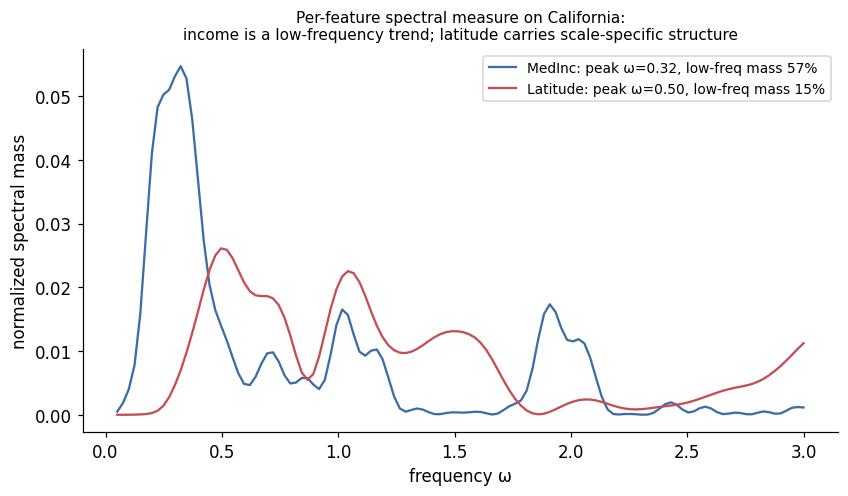

,peak ω,low-freq mass (<0.5)
MedInc,0.32,57%
Latitude,0.5,15%


In [8]:
ch08.make_california_density_figure(seed=0)
plt.show()
dens = ch08.california_spectral_density(seed=0)
pd.DataFrame({f: {"peak ω": round(c["peak"], 2),
                  "low-freq mass (<0.5)": f"{c['low_freq_mass']:.0%}"}
              for f, c in dens.items()}).T

Median income is a low-frequency trend; latitude carries structure spread to higher scales.
You can say which feature carries a trend and which carries scale-specific structure straight
off the measure — the inspectable geometry a learned kernel buys you.

## 8.5  Interactive: move the bandwidth and the frequency

Slide the readout bandwidth T and the periodic frequency of the target, and watch the fit and
its extrapolation respond. A small T is a sharp, local kernel; a larger T spreads similarity.
The frequency support is read off the data, so the recovered peak tracks the true frequency.

In [9]:
from ipywidgets import interact, FloatSlider


def explore(T=1.0, freq=3.0):
    X, y, true_f = ch08.smooth_plus_periodic(n=80, freq=freq, seed=0)
    f_star = ch08.dominant_frequency(X, y, mu_max=2.0 * freq)
    omegas = np.array([0.0, 0.5, f_star, 2.0 * f_star])
    kern = ch08.SpectralLaplaceKernel(omegas, np.ones(4), T=T)
    Xg = np.linspace(0, 1.8, 320)
    truth = 0.8 * (Xg - 0.5) ** 2 + 0.5 * np.sin(2 * np.pi * true_f * Xg)
    alpha = np.linalg.solve(kern.gram(X, X) + 1e-3 * np.eye(len(X)), y - y.mean())
    pred = kern.gram(Xg, X) @ alpha + y.mean()
    fig, ax = plt.subplots(figsize=(8.5, 4.2), constrained_layout=True)
    ax.axvspan(1.0, 1.8, color="#f0f0f0", zorder=0, label="extrapolation")
    ax.scatter(X, y, s=12, c="#444", zorder=3, label="data")
    ax.plot(Xg, truth, "k--", lw=1, zorder=2, label="truth")
    ax.plot(Xg, pred, color="#c44e52", lw=2, zorder=4, label="spectral-Laplace fit")
    ax.set_title(f"recovered freq {f_star:.2f} (true {true_f:.1f}), bandwidth T={T:.2f}")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)
    plt.show()


interact(explore,
         T=FloatSlider(min=0.1, max=4.0, step=0.1, value=1.0, description="bandwidth T"),
         freq=FloatSlider(min=1.0, max=5.0, step=0.5, value=3.0, description="frequency"));

interactive(children=(FloatSlider(value=1.0, description='bandwidth T', max=4.0, min=0.1), FloatSlider(value=3…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the fused Laplace kernel's unit diagonal and PSD-ness for your own banks.

In [10]:
# TODO: build a SpectralLaplaceKernel with two banks (weights summing to 1) and check
#       diag + min eigenvalue
diag_mean = min_eig = None
print(diag_mean, min_eig)

None None


<details><summary>Solution</summary>

```python
k = ch08.SpectralLaplaceKernel([0.0, 1.0, 2.0], [1.0, 1.0, 1.0], T=[0.5, 2.0], w=[0.5, 0.5])
K = k.gram(X, X)
diag_mean = float(np.diag(K).mean())               # 1.000  (each bank unit-diagonal, w sums to 1)
min_eig = float(np.linalg.eigvalsh(K).min())       # >= 0   (convex combo of PSD banks)
print(diag_mean, min_eig)
```
Each Laplace bank has k(x,x) = 1, and a convex combination of PSD kernels is PSD with a
convex combination of unit diagonals — still unit.
</details>

**(⋆)** Show the readout sets the roughness: fit the rough OU path with the Laplace readout
and with the RBF readout under the *same* query-fold bandwidth selection, and compare RMSE.

In [11]:
# TODO: call ch08.roughness_ladder_demo and read off laplace_rmse vs rbf_rmse
laplace_rmse = rbf_rmse = None
print(laplace_rmse, rbf_rmse)

None None


<details><summary>Solution</summary>

```python
r = ch08.roughness_ladder_demo(seed=0)
laplace_rmse = round(r["laplace_rmse"], 3)   # ~0.249
rbf_rmse = round(r["rbf_rmse"], 3)           # ~0.352
print(laplace_rmse, rbf_rmse)
```
Same spectrum class, same selection — only the readout differs. The Laplace cusp reaches the
H^½ rough class the Gaussian's C^∞ RKHS excludes at any sample size.
</details>

---
*Companion to Chapter 8 of **The Learned Kernel**. The finite spectral-Laplace kernel, the
roughness ladder and the recovery beat come from `lkbook.chapters.ch08` — the same code the
book's figures are generated from. Related Substack reading: "What Makes a Kernel Learnable?"*